In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import os
import time
from mpl_toolkits.mplot3d import Axes3D 
import scipy
import sys

In [2]:
import gymnasium
from gymnasium import spaces

In [3]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common import results_plotter
import autograd, autograd.core, autograd.extend, autograd.tracer  
import autograd.numpy as anp 
from deap import base
from deap import creator
from deap import tools
import random
import seaborn as sns
import gudhi as gd
from stable_baselines3.common.vec_env import SubprocVecEnv
from pathos.multiprocessing import ProcessingPool as Pool

In [4]:
from topology_utils import deconstruct, calculate_smoothness_metric, count_islands_dfs

In [5]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

In [6]:
sys.path.append('../../../../../../ocean_intella/ocean_intella/pipelay_profile_optimization/')

In [7]:
import elitism

In [8]:
x0, y0 = 32, 32

### Finite Element Model

In [9]:
class ObjectView(object):
    def __init__(self, d): self.__dict__ = d
    
def get_args(normals, forces, density=1e-4):  # Manage the problem setup parameters
    width = normals.shape[0] - 1
    height = normals.shape[1] - 1
    fixdofs = np.flatnonzero(normals.ravel())
    alldofs = np.arange(2 * (width + 1) * (height + 1))
    freedofs = np.sort(list(set(alldofs) - set(fixdofs)))
    params = {
      # material properties
      'young': 1, 'young_min': 1e-9, 'poisson': 0.3, 'g': 0,
      # constraints
      'density': density, 'xmin': 0.001, 'xmax': 1.0,
      # input parameters
      'nelx': width, 'nely': height, 'mask': 1, 'penal': 3.0, 'filter_width': 1,
      'freedofs': freedofs, 'fixdofs': fixdofs, 'forces': forces.ravel(),
      # optimization parameters
      'opt_steps': 80, 'print_every': 10}
#     print(params)
    return ObjectView(params)

def mbb_beam(width=y0, height=x0, density=1e-4, y=1, x=0, rd=0):  # textbook beam example
    normals = np.zeros((width + 1, height + 1, 2))
    normals[0, 0, x] = 1
    normals[0, 0, y] = 1
    normals[0, -1, x] = 1
    normals[0, -1, y] = 1
    forces = np.zeros((width + 1, height + 1, 2))
    forces[-1, rd, y] = 1
    return normals, forces, density

In [10]:
def young_modulus(x, e_0, e_min, p=3):
    return e_min + x ** p * (e_0 - e_min)

def physical_density(x, args, volume_contraint=False, use_filter=True):
    x = args.mask * x.reshape(args.nely, args.nelx)  # reshape from 1D to 2D
    return gaussian_filter(x, args.filter_width) if use_filter else x  # maybe filter

def mean_density(x, args, volume_contraint=False, use_filter=True):
    return anp.mean(physical_density(x, args, volume_contraint, use_filter)) / anp.mean(args.mask)

In [11]:
def objective(x, args, volume_contraint=False, use_filter=True):
    kwargs = dict(penal=args.penal, e_min=args.young_min, e_0=args.young)
    x_phys = physical_density(x, args, volume_contraint=volume_contraint, use_filter=use_filter)
    ke     = get_stiffness_matrix(args.young, args.poisson)  # stiffness matrix
    u      = displace(x_phys, ke, args.forces, args.freedofs, args.fixdofs, **kwargs)
    c      = compliance(x_phys, u, ke, **kwargs)
    return c

In [12]:
def gaussian_filter(x, width): # 2D gaussian blur/filter
    return scipy.ndimage.gaussian_filter(x, width, mode='reflect')

def _gaussian_filter_vjp(ans, x, width): # gives the gradient of orig. function w.r.t. x
    del ans, x  # unused
    return lambda g: gaussian_filter(g, width)

In [13]:
def compliance(x_phys, u, ke, *, penal=3, e_min=1e-9, e_0=1):
    nely, nelx = x_phys.shape
    ely, elx = anp.meshgrid(range(nely), range(nelx))  # x, y coords for the index map

    n1 = (nely+1)*(elx+0) + (ely+0)  # nodes
    n2 = (nely+1)*(elx+1) + (ely+0)
    n3 = (nely+1)*(elx+1) + (ely+1)
    n4 = (nely+1)*(elx+0) + (ely+1)
    all_ixs = anp.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n3, 2*n3+1, 2*n4, 2*n4+1])
    u_selected = u[all_ixs]  # select from u matrix

    ke_u = anp.einsum('ij,jkl->ikl', ke, u_selected)  # compute x^penal * U.T @ ke @ U
    ce = anp.einsum('ijk,ijk->jk', u_selected, ke_u)
    C = young_modulus(x_phys, e_0, e_min, p=penal) * ce.T
    return anp.sum(C)

def get_stiffness_matrix(e, nu):  # e=young's modulus, nu=poisson coefficient
    k = anp.array([1/2-nu/6, 1/8+nu/8, -1/4-nu/12, -1/8+3*nu/8,
                -1/4+nu/12, -1/8-nu/8, nu/6, 1/8-3*nu/8])
    return e/(1-nu**2)*anp.array([[k[0], k[1], k[2], k[3], k[4], k[5], k[6], k[7]],
                               [k[1], k[0], k[7], k[6], k[5], k[4], k[3], k[2]],
                               [k[2], k[7], k[0], k[5], k[6], k[3], k[4], k[1]],
                               [k[3], k[6], k[5], k[0], k[7], k[2], k[1], k[4]],
                               [k[4], k[5], k[6], k[7], k[0], k[1], k[2], k[3]],
                               [k[5], k[4], k[3], k[2], k[1], k[0], k[7], k[6]],
                               [k[6], k[3], k[4], k[1], k[2], k[7], k[0], k[5]],
                               [k[7], k[2], k[1], k[4], k[3], k[6], k[5], k[0]]])

In [14]:
def get_k(stiffness, ke):
    # Constructs sparse stiffness matrix k (used in the displace fn)
    # First, get position of the nodes of each element in the stiffness matrix
    nely, nelx = stiffness.shape
    ely, elx = anp.meshgrid(range(nely), range(nelx))  # x, y coords
    ely, elx = ely.reshape(-1, 1), elx.reshape(-1, 1)

    n1 = (nely+1)*(elx+0) + (ely+0)
    n2 = (nely+1)*(elx+1) + (ely+0)
    n3 = (nely+1)*(elx+1) + (ely+1)
    n4 = (nely+1)*(elx+0) + (ely+1)
    edof = anp.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n3, 2*n3+1, 2*n4, 2*n4+1])
    edof = edof.T[0]
    x_list = anp.repeat(edof, 8)  # flat list pointer of each node in an element
    y_list = anp.tile(edof, 8).flatten()  # flat list pointer of each node in elem

    # make the global stiffness matrix K
    kd = stiffness.T.reshape(nelx*nely, 1, 1)
    value_list = (kd * anp.tile(ke, kd.shape)).flatten()
    return value_list, y_list, x_list

def displace(x_phys, ke, forces, freedofs, fixdofs, *, penal=3, e_min=1e-9, e_0=1):
    # Displaces the load x using finite element techniques (solve_coo=most of runtime)
    stiffness = young_modulus(x_phys, e_0, e_min, p=penal)
    k_entries, k_ylist, k_xlist = get_k(stiffness, ke)

    index_map, keep, indices = _get_dof_indices(freedofs, fixdofs, k_ylist, k_xlist)

    u_nonzero = solve_coo(k_entries[keep], indices, forces[freedofs], sym_pos=True)
    u_values = anp.concatenate([u_nonzero, anp.zeros(len(fixdofs))])
    return u_values[index_map]

In [15]:
def _get_dof_indices(freedofs, fixdofs, k_xlist, k_ylist):
    index_map = inverse_permutation(anp.concatenate([freedofs, fixdofs]))
    keep = anp.isin(k_xlist, freedofs) & anp.isin(k_ylist, freedofs)
    # Now we index an indexing array that is being indexed by the indices of k
    i = index_map[k_ylist][keep]
    j = index_map[k_xlist][keep]
    return index_map, keep, anp.stack([i, j])

def inverse_permutation(indices):  # reverses an index operation
    inverse_perm = np.zeros(len(indices), dtype=anp.int64)
    inverse_perm[indices] = np.arange(len(indices), dtype=anp.int64)
    return inverse_perm

In [16]:
def _get_solver(a_entries, a_indices, size, sym_pos):
    # a is (usu.) symmetric positive; could solve 2x faster w/sksparse.cholmod.cholesky(a).solve_A
    a = scipy.sparse.coo_matrix((a_entries, a_indices), shape=(size,)*2).tocsc()
    return scipy.sparse.linalg.splu(a).solve


def solve_coo(a_entries, a_indices, b, sym_pos=False):
    solver = _get_solver(a_entries, a_indices, b.size, sym_pos)
    return solver(b)

def grad_solve_coo_entries(ans, a_entries, a_indices, b, sym_pos=False):
    def jvp(grad_ans):
        lambda_ = solve_coo(a_entries, a_indices if sym_pos else a_indices[::-1],
                            grad_ans, sym_pos)
        i, j = a_indices
        return -lambda_[i] * ans[j]
    return jvp

In [17]:
def fast_stopt(args, x):

    reshape = lambda x: x.reshape(args.nely, args.nelx)
    objective_fn = lambda x: objective(reshape(x), args)
#     constraint = lambda params: mean_density(reshape(params), args) - args.density
    constraint = lambda params: mean_density(reshape(params), args) 
    value = objective_fn(x)
    const = constraint(x)
    return value, const

In [18]:
def draw(X):  
    plt.figure(dpi=50) 
    print('\nFinal Cantilever beam design:')
    plt.imshow(X) 
    plt.show()

### Genetic Modelling

In [19]:
# Genetic Algorithm constants:
POPULATION_SIZE = 300
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual
MAX_GENERATIONS = 2000
HALL_OF_FAME_SIZE = 30

In [20]:
PENALTY_VALUE = 1000.0 

In [21]:
# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

In [22]:
toolbox = base.Toolbox()

In [23]:
# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

In [24]:
# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)

In [25]:
# create an operator that randomly returns 0 or 1:
toolbox.register("zeroOrOne", random.randint, 0, 1)

In [26]:
# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", 
                 tools.initRepeat,
                 creator.Individual,
                 toolbox.zeroOrOne, 
                 x0*y0+4)

In [27]:
# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", 
                 tools.initRepeat, 
                 list, 
                 toolbox.individualCreator)

In [28]:
# convert a binary list to decimal
def binatodeci(binary):
    return sum(val*(2**idx) for idx, val in enumerate(reversed(binary)))

In [29]:
class Prev:
    def __init__(self):
        self.prev = 100

In [30]:
T=Prev()

In [31]:
# fitness calculation
def staticFEM(individual):
    
    args = get_args(*mbb_beam(rd=0))
    
    x = np.array([t if t==1 else 1e-4 for t in individual[:-4]]) 
    
    
    try:
        if np.sum(x)/(x0*y0) > 0.5:
            tmp, const = fast_stopt(args, x)
            T.prev=tmp
            if const>(55+binatodeci(individual[-4:]))/100:
                return PENALTY_VALUE, 
        else:
            return T.prev,
    except:
        return PENALTY_VALUE, 
    
    
    return tmp,  # return a tuple

In [32]:
toolbox.register("evaluate", staticFEM)
pool = Pool(8)
toolbox.register("map", pool.map)

# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/(x0*y0+4))

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [33]:
# Genetic Algorithm flow:
def main():

    # create initial population (generation 0):
    population = toolbox.populationCreator(n=POPULATION_SIZE)

    # prepare the statistics object:
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("avg", np.mean)

    # define the hall-of-fame object:
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    # perform the Genetic Algorithm flow with hof feature added:
    population, logbook = elitism.eaSimpleWithElitism(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                              ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

    # print best solution found:
    best = hof.items[0]
    print("-- Best Individual = ", best)
    print("-- Best Fitness = ", best.fitness.values[0])
    print()
    
    x = np.array(best[:-4]).astype(np.float64).reshape(x0,y0)
    
    args = get_args(*mbb_beam(rd=0))
    print(fast_stopt(args, x))
    
    draw(x)
    

    # extract statistics:
    minFitnessValues, meanFitnessValues = logbook.select("min", "avg")

    # plot statistics:
    sns.set_style("whitegrid")
    plt.plot(minFitnessValues, color='red')
    plt.plot(meanFitnessValues, color='green')
  
    plt.xlabel('Generation')
    plt.ylabel('Min / Average Fitness')
    plt.title('Min and Average fitness over Generations')
    plt.show()    
    return x

gen	nevals	min	avg    
0  	300   	100	36836.7
1  	249   	97.6989	1243.04
2  	247   	97.6989	2528.78
3  	248   	93.4104	1708.5 
4  	239   	93.4104	391.652
5  	247   	87.5899	865.226
6  	234   	87.5899	252.04 
7  	243   	83.2347	2748.82
8  	239   	83.2347	6570.7 
9  	237   	82.2498	147.089
10 	254   	78.3682	494.64 
11 	245   	76.5619	482.549
12 	240   	73.663 	96.2402
13 	238   	66.4448	85.9554
14 	240   	66.4448	81.5276
15 	247   	64.3489	77.481 
16 	249   	64.3489	74.3774
17 	259   	63.7843	71.6712
18 	257   	59.0289	69.1972
19 	250   	57.8011	66.6327
20 	244   	55.9945	64.78  
21 	247   	55.9945	62.9407
22 	257   	55.2629	61.254 
23 	250   	53.3956	59.5649
24 	236   	52.9797	57.7159
25 	241   	51.4567	56.2517
26 	251   	50.9529	55.0339
27 	250   	50.0008	54.0331
28 	258   	49.5403	53.0409
29 	239   	48.3206	52.1187
30 	253   	47.5471	51.2231
31 	241   	47.4203	50.4822
32 	250   	46.1084	56.0011
33 	242   	46.1084	58.4486
34 	251   	46.1084	64.1527
35 	242   	45.534 	79.4796
36 	244  

303	247   	26.5251	127.178
304	252   	26.5251	140.146
305	256   	26.5251	117.43 
306	255   	26.5105	143.38 
307	248   	26.5105	123.915
308	251   	26.4978	136.88 
309	249   	26.4666	117.407
310	248   	26.448 	110.907
311	258   	26.3891	143.343
312	253   	26.3891	169.314
313	247   	26.3841	107.63 
314	244   	26.3652	117.36 
315	237   	26.3372	107.613
316	240   	26.3327	133.543
317	241   	26.2651	110.838
318	242   	26.2639	130.296
319	240   	26.222 	130.236
320	248   	26.222 	123.715
321	254   	26.222 	117.2  
322	247   	26.222 	133.415
323	250   	26.1961	97.6946
324	250   	26.1921	110.66 
325	247   	26.1921	123.665
326	245   	26.1719	156.09 
327	252   	26.148 	133.36 
328	245   	26.148 	117.122
329	242   	26.148 	126.858
330	240   	26.1388	113.855
331	246   	26.124 	104.101
332	260   	26.124 	136.562
333	245   	26.1214	162.528
334	247   	26.1096	172.244
335	239   	26.0888	149.52 
336	250   	26.0888	130.033
337	240   	26.0814	130.027
338	252   	26.0632	133.269
339	242   	26.053 	181.965
3

607	249   	23.7585	108.413
608	238   	23.7496	98.6502
609	250   	23.7496	134.438
610	256   	23.7496	137.686
611	244   	23.7228	134.429
612	232   	23.7228	118.152
613	242   	23.7154	147.435
614	249   	23.7061	134.414
615	252   	23.6971	124.642
616	252   	23.6971	137.675
617	246   	23.6872	85.5891
618	241   	23.6687	147.394
619	243   	23.6687	144.131
620	243   	23.6644	127.854
621	259   	23.6337	137.613
622	249   	23.6337	118.091
623	247   	23.6337	134.347
624	246   	23.6337	134.345
625	246   	23.6337	140.874
626	235   	23.6337	114.807
627	250   	23.619 	134.329
628	253   	23.619 	153.852
629	254   	23.5951	121.307
630	240   	23.5907	121.296
631	248   	23.5779	144.069
632	258   	23.5779	163.595
633	251   	23.5779	137.552
634	241   	23.5518	140.798
635	244   	23.5518	114.758
636	236   	23.5429	150.542
637	243   	23.5429	150.544
638	232   	23.5314	144.022
639	237   	23.5276	134.248
640	242   	23.5233	160.281
641	252   	23.5233	183.057
642	241   	23.5125	143.994
643	257   	23.5071	166.773
6

911	242   	22.662 	156.26 
912	253   	22.662 	139.965
913	252   	22.6592	139.967
914	251   	22.657 	152.989
915	254   	22.657 	139.961
916	242   	22.657 	113.894
917	239   	22.6544	120.41 
918	236   	22.6544	172.529
919	246   	22.6544	120.405
920	243   	22.6334	123.658
921	245   	22.6334	110.624
922	241   	22.6334	156.232
923	252   	22.6334	136.685
924	247   	22.6334	152.977
925	243   	22.6334	153.021
926	243   	22.6334	152.975
927	247   	22.6296	162.747
928	244   	22.6296	156.267
929	248   	22.6249	146.457
930	245   	22.6249	159.491
931	254   	22.6196	162.756
932	240   	22.6172	152.97 
933	245   	22.6154	152.972
934	235   	22.6148	143.192
935	247   	22.6148	169.261
936	240   	22.6148	91.0617
937	243   	22.6148	133.403
938	242   	22.6148	159.471
939	252   	22.6139	133.411
940	251   	22.6138	152.952
941	256   	22.6049	143.17 
942	245   	22.6049	117.106
943	243   	22.6049	117.104
944	251   	22.6049	156.207
945	234   	22.6032	126.877
946	239   	22.6032	143.167
947	247   	22.603 	120.358
9

1207	249   	22.3914	139.743
1208	252   	22.3914	136.493
1209	244   	22.3914	133.211
1210	235   	22.3914	133.205
1211	251   	22.3885	149.494
1212	241   	22.3865	133.229
1213	249   	22.3827	129.977
1214	259   	22.3789	146.258
1215	247   	22.3776	133.197
1216	244   	22.3767	110.385
1217	244   	22.3767	139.709
1218	239   	22.3747	136.447
1219	257   	22.3747	156.001
1220	254   	22.372 	133.187
1221	241   	22.372 	142.977
1222	240   	22.3668	123.406
1223	249   	22.3668	107.132
1224	237   	22.3668	146.221
1225	256   	22.3668	136.437
1226	247   	22.3668	129.923
1227	242   	22.3668	113.633
1228	254   	22.3668	152.733
1229	244   	22.3668	113.626
1230	242   	22.3668	123.398
1231	244   	22.3668	162.507
1232	239   	22.3657	129.916
1233	251   	22.3657	159.246
1234	247   	22.3657	162.503
1235	251   	22.3657	139.693
1236	245   	22.3657	90.8082
1237	246   	22.3657	90.8144
1238	251   	22.3657	81.0282
1239	244   	22.3657	71.2529
1240	244   	22.3657	48.4759
1241	244   	22.3657	61.4824
1242	245   	22.3657	

1500	253   	22.2914	38.5937
1501	245   	22.2914	28.8131
1502	246   	22.2914	28.8131
1503	256   	22.2914	54.9167
1504	252   	22.2914	45.1425
1505	257   	22.2914	54.8864
1506	260   	22.2914	48.3779
1507	260   	22.2914	45.1226
1508	252   	22.2914	51.6322
1509	234   	22.2914	41.855 
1510	256   	22.2914	35.3389
1511	247   	22.2914	45.1192
1512	236   	22.2914	45.1101
1513	251   	22.2914	51.6279
1514	242   	22.2914	32.0739
1515	249   	22.2914	38.5916
1516	247   	22.2914	41.8523
1517	254   	22.2914	45.1071
1518	250   	22.2914	38.5947
1519	251   	22.2914	32.0733
1520	251   	22.2914	38.5891
1521	243   	22.2914	25.5532
1522	234   	22.2914	45.1092
1523	242   	22.2914	51.6261
1524	236   	22.2914	38.5912
1525	241   	22.2914	35.3296
1526	245   	22.2914	45.1114
1527	235   	22.2914	41.8488
1528	250   	22.2914	38.589 
1529	244   	22.2914	54.8863
1530	242   	22.2914	45.1086
1531	234   	22.2914	41.8493
1532	243   	22.2914	45.109 
1533	248   	22.2914	38.5907
1534	242   	22.2914	41.8521
1535	248   	22.2914	

1793	250   	22.2914	45.1073
1794	246   	22.2914	54.8855
1795	250   	22.2914	45.1058
1796	246   	22.2914	41.854 
1797	251   	22.2914	32.0725
1798	247   	22.2914	32.0769
1799	245   	22.2914	45.1108
1800	226   	22.2914	48.3726
1801	245   	22.2914	35.3312
1802	235   	22.2914	38.5955
1803	244   	22.2914	45.1088
1804	254   	22.2914	35.3408
1805	242   	22.2914	41.8552
1806	248   	22.2914	41.8472
1807	253   	22.2884	41.8603
1808	245   	22.2884	48.433 
1809	247   	22.2884	38.5984
1810	242   	22.2884	38.5886
1811	252   	22.2884	38.5938
1812	244   	22.2884	51.6263
1813	245   	22.2884	41.8498
1814	252   	22.2884	48.3665
1815	248   	22.2884	38.596 
1816	236   	22.2884	41.847 
1817	236   	22.2884	48.3949
1818	255   	22.2884	41.8595
1819	247   	22.2884	48.3681
1820	238   	22.2884	71.1841
1821	244   	22.2884	100.524
1822	247   	22.2884	97.2529
1823	244   	22.2831	120.068
1824	256   	22.2831	129.847
1825	251   	22.2831	103.775
1826	260   	22.2831	103.787
1827	257   	22.2831	120.074
1828	248   	22.2831	

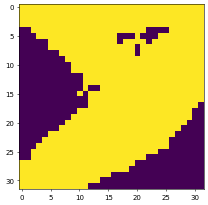

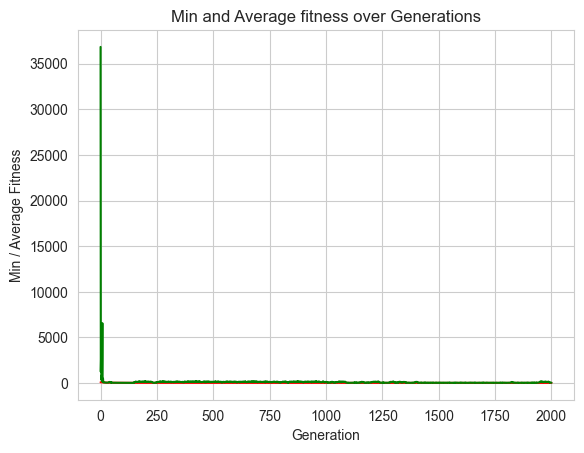

In [34]:
if __name__ == "__main__":
    start = time.time()
    top_ = main()
    end = time.time()


Final Cantilever beam design:


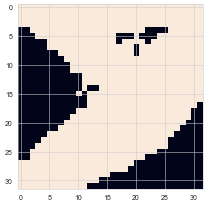

In [35]:
draw(top_)

### RL model

In [36]:
class Model:
    def __init__(self, x):
        self.flag_ = True
        self.n, self.m = x.shape
        self.actions_dic={} 
    
        k=0
        for i in range(self.n):
            for j in range(self.m):
                self.actions_dic[k]=(i,j)
                k+=1
        
    def action_space_(self, action, X):
        x,y=self.actions_dic[action]
        X[x][y]=1

In [37]:
class CantileverEnv(gymnasium.Env):
    
    metadata = {"render.modes": ["human"]}

    def __init__(self,x1,y1):
        super().__init__()
        self.x0=x1
        self.y0=y1
        
        DIM =  self.x0 * self.y0
        N_DISCRETE_ACTIONS = self.x0 * self.y0
        
        self.action_space = spaces.Discrete(N_DISCRETE_ACTIONS)
        self.observation_space = spaces.Box(low=np.array([-1e10 for x in range(DIM)]),
                                            high=np.array([1e10 for y in range(DIM)]),
                                            shape=(DIM,),
                                           dtype=np.float64)
        
        self.x = np.ones(( self.x0, self.y0))*1e-04
    
        self.M=Model(self.x)
        
        self.reward=0
        self.step_=0
        self.needs_reset = True
        self.ext_reward=0

        
    def step(self, action):
        
        self.M.action_space_(action, self.x)        
        self.step_+=1
               
        done=False
                  
        if self.step_ > 0.8*self.x0 * self.y0:                    # to tune 
            done=True            
            
        if self.needs_reset:
            raise RuntimeError("Tried to step environment that needs reset")
            
        if done:
            self.needs_reset = True
                         
        
        return self.x.reshape(self.x.shape[0]*self.x.shape[1]), self.ext_reward, done, False, dict()

    def reset(self, seed=0):
                   
        self.x = np.ones((self.x0, self.y0))*1e-04

        self.reward=0
        self.needs_reset = False
        self.step_=0
        self.ext_reward=0

        return self.x.reshape(self.x.shape[0]*self.x.shape[1]),{}

    def render(self, mode="human"):
        pass   

    def close(self):
        pass

In [38]:
class SaveOnBestTrainingRewardCallback(BaseCallback):
    """
    Callback for saving a model (the check is done every ``check_freq`` steps)
    based on the training reward (in practice, we recommend using ``EvalCallback``).

    :param check_freq: (int)
    :param log_dir: (str) Path to the folder where the model will be saved.
      It must contains the file created by the ``Monitor`` wrapper.
    :param verbose: (int)
    """

    def __init__(self, check_freq: int, log_dir: str, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.log_dir = log_dir
        self.save_path = os.path.join(log_dir, "best_model")
        self.best_mean_reward = -np.inf

    def _init_callback(self) -> None:
        # Create folder if needed
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:
            
            
            
            # Retrieve training reward
            x, y = ts2xy(load_results(self.log_dir), "timesteps")

            if len(x) > 0:
                # Mean training reward over the last 100 episodes
                
                mean_reward = np.mean(y[-100:])
                
                if self.verbose > 0:
                    print(f"Num timesteps: {self.num_timesteps}")
                    print(
                        f"Best mean reward: {self.best_mean_reward:.2f} - Last mean reward per episode: {mean_reward:.2f}"
                    )

                # New best model, you could save the agent here
                if mean_reward > self.best_mean_reward:
                    self.best_mean_reward = mean_reward
                    # Example for saving best model
                    if self.verbose > 0:
                        print(f"Saving new best model to {self.save_path}.zip")
                    self.model.save(self.save_path)

        return True

In [39]:
def reconstruct_3d_structure(xy_plane, yz_plane, xz_plane):
    """
    Reconstructs a 3D structure from three 2D projections using extrusion and intersection.

    Parameters:
        xy_plane (ndarray): 2D binary array (X by Y) projection in XY plane.
        yz_plane (ndarray): 2D binary array (Y by Z) projection in YZ plane.
        xz_plane (ndarray): 2D binary array (X by Z) projection in XZ plane.

    Returns:
        volume (ndarray): 3D binary array (X by Y by Z) representing the reconstructed structure.
    """
    x_dim, y_dim = xy_plane.shape
    y_dim2, z_dim = yz_plane.shape
    x_dim2, z_dim2 = xz_plane.shape

    assert x_dim == x_dim2, "X dimensions mismatch between XY and XZ planes."
    assert y_dim == y_dim2, "Y dimensions mismatch between XY and YZ planes."
    assert z_dim == z_dim2, "Z dimensions mismatch between YZ and XZ planes."

    # Extrude XY along Z
    xy_extruded = np.repeat(xy_plane[:, :, np.newaxis], z_dim, axis=2)

    # Extrude YZ along X
    yz_extruded = np.repeat(yz_plane[np.newaxis, :, :], x_dim, axis=0)

    # Extrude XZ along Y
    xz_extruded = np.repeat(xz_plane[:, np.newaxis, :], y_dim, axis=1)

    # Intersect all three extrusions
    volume = xy_extruded & yz_extruded & xz_extruded

    return volume.astype(np.uint8)  # or bool, depending on your needs

In [40]:
def compute_single_reward(args_tuple):
    grid_data, action_slice, task_index, x0, y0 = args_tuple
    
    gr = deconstruct(grid_data, action_slice.reshape(x0//4, y0//4), task_index, x0, y0)
    constI = np.sum(gr) / (x0 * y0)
   
    if constI > 0.65:                     # to tune 
        args = get_args(*mbb_beam(rd=0))
        tmp, const = fast_stopt(args, gr)  
        reward = 1/tmp + 1/calculate_smoothness_metric(gr.reshape(x0, y0))
        if count_islands_dfs(gr) == 1:
            reward *= 10

        return reward, constI
    return 0.0, constI

In [41]:
class CrossRewardEnv(gymnasium.Env):
    def __init__(self):
        super().__init__()
        self.env0 = CantileverEnv(x0//4,y0//4)
        self.env1 = CantileverEnv(x0//4,y0//4)
        self.env2 = CantileverEnv(x0//4,y0//4)
        self.env3 = CantileverEnv(x0//4,y0//4)
        self.env4 = CantileverEnv(x0//4,y0//4)
        self.env5 = CantileverEnv(x0//4,y0//4)
        self.env6 = CantileverEnv(x0//4,y0//4)
        self.env7 = CantileverEnv(x0//4,y0//4)
        self.env8 = CantileverEnv(x0//4,y0//4)
        self.env9 = CantileverEnv(x0//4,y0//4)
        self.env10 = CantileverEnv(x0//4,y0//4)
        self.env11 = CantileverEnv(x0//4,y0//4)
        self.env12 = CantileverEnv(x0//4,y0//4)
        self.env13 = CantileverEnv(x0//4,y0//4)
        self.env14 = CantileverEnv(x0//4,y0//4)
        self.env15 = CantileverEnv(x0//4,y0//4)

        self.observation_space = spaces.Dict({
            'plane0': self.env0.observation_space,
            'plane1': self.env1.observation_space,
            'plane2': self.env2.observation_space,
            'plane3': self.env3.observation_space,
            'plane4': self.env4.observation_space,
            'plane5': self.env5.observation_space,
            'plane6': self.env6.observation_space,
            'plane7': self.env7.observation_space,
            'plane8': self.env8.observation_space,
            'plane9': self.env9.observation_space,
            'plane10': self.env10.observation_space,
            'plane11': self.env11.observation_space,
            'plane12': self.env12.observation_space,
            'plane13': self.env13.observation_space,
            'plane14': self.env14.observation_space,
            'plane15': self.env15.observation_space,
        })

        self.action_space = spaces.MultiDiscrete([(x0*y0)//16 for i in range(16)])
        self.step1_ = 0
        self.grid = np.where( top_ == 0, 1e-04, top_)      
        self.grid_glob = np.where( top_ == 0, 1e-04, top_)
        self.x0=x0
        self.y0=y0

    def reset(self, seed=0):
        obs0, info0 = self.env0.reset()
        obs1, info1 = self.env1.reset()
        obs2, info2 = self.env2.reset()
        obs3, info3 = self.env3.reset()
        obs4, info4 = self.env4.reset()
        obs5, info5 = self.env5.reset()
        obs6, info6 = self.env6.reset()
        obs7, info7 = self.env7.reset()
        obs8, info8 = self.env8.reset()
        obs9, info9 = self.env9.reset()
        obs10, info10 = self.env10.reset()
        obs11, info11 = self.env11.reset()
        obs12, info12 = self.env12.reset()
        obs13, info13 = self.env13.reset()
        obs14, info14 = self.env14.reset()
        obs15, info15 = self.env15.reset()
        self.step1_=0
        self.grid_glob = np.where(top_ == 0, 1e-04, top_) 
        return {
            'plane0': obs0,
            'plane1': obs1,
            'plane2': obs2,
            'plane3': obs3,
            'plane4': obs4,
            'plane5': obs5,
            'plane6': obs6,
            'plane7': obs7,
            'plane8': obs8,
            'plane9': obs9,
            'plane10': obs10,
            'plane11': obs11,
            'plane12': obs12,
            'plane13': obs13,
            'plane14': obs14,
            'plane15': obs15,
        }, {
            'plane0': info0,
            'plane1': info1,
            'plane2': info2,
            'plane3': info3,
            'plane4': info4,
            'plane5': info5,
            'plane6': info6,
            'plane7': info7,
            'plane8': info8,
            'plane9': info9,
            'plane10': info10,
            'plane11': info11,
            'plane12': info12,
            'plane13': info13,
            'plane14': info14,
            'plane15': info15,
        }

    def step(self, action):
        a0 = action[0]
        a1 = action[1]
        a2 = action[2]
        a3 = action[3]
        a4 = action[4]
        a5 = action[5]
        a6 = action[6]
        a7 = action[7]
        a8 = action[8]
        a9 = action[9]
        a10 = action[10]
        a11 = action[11]
        a12 = action[12]
        a13 = action[13]
        a14 = action[14]
        a15 = action[15]
        
        
        obs0, r0, done0,_, info0 = self.env0.step(a0)
        obs1, r1, done1,_, info1 = self.env1.step(a1)
        obs2, r2, done2,_, info2 = self.env2.step(a2)
        obs3, r3, done3,_, info3 = self.env3.step(a3)
        obs4, r4, done4,_, info4 = self.env4.step(a4)
        obs5, r5, done5,_, info5 = self.env5.step(a5)
        obs6, r6, done6,_, info6 = self.env6.step(a6)
        obs7, r7, done7,_, info7 = self.env7.step(a7)
        obs8, r8, done8,_, info8 = self.env8.step(a8)
        obs9, r9, done9,_, info9 = self.env9.step(a9)
        obs10, r10, done10,_, info10 = self.env10.step(a10)
        obs11, r11, done11,_, info11 = self.env11.step(a11)
        obs12, r12, done12,_, info12 = self.env12.step(a12)
        obs13, r13, done13,_, info13 = self.env13.step(a13)
        obs14, r14, done14,_, info14 = self.env14.step(a14)
        obs15, r15, done15,_, info15 = self.env15.step(a15)
       
        OBS=[obs0,obs1,obs2,obs3,obs4,obs5,obs6,obs7,obs8,obs9,obs10,obs11,obs12,obs13,obs14,obs15]    
        RE =[self.env0.ext_reward,
             self.env1.ext_reward,
             self.env2.ext_reward,
             self.env3.ext_reward,
             self.env4.ext_reward,
             self.env5.ext_reward,
             self.env6.ext_reward,
             self.env7.ext_reward,
             self.env8.ext_reward,
             self.env9.ext_reward,
             self.env10.ext_reward,
             self.env11.ext_reward,
             self.env12.ext_reward,
             self.env13.ext_reward,
             self.env14.ext_reward,
             self.env15.ext_reward,
            ] 
        
        task_args = []
       
        for i in range(len(OBS)):
            task_args.append((self.grid, OBS[i], i, self.x0, self.y0))
            self.grid_glob = deconstruct(self.grid_glob, OBS[i].reshape(self.x0//4,self.y0//4), i, self.x0, self.y0)
        results  = pool.map(compute_single_reward, task_args)
        rewards_list, coI = zip(*results)
    
        for i in range(len(OBS)): 
            RE[i]=rewards_list[i] 
                            
        self.step1_+=1
     
        Do=(np.sum(coI)/len(OBS) > 0.67)                     # to tune 
        done = (done0 or done1 or done2 or done3 or done4 or done5 or done6 or
        done7 or done8 or done9 or done10 or done11 or done12 or done13 or done14 or done15 or bool(Do))
        
        args_glob = get_args(*mbb_beam(rd=0))
        tmp_glob, const_glob = fast_stopt(args_glob, self.grid_glob)
        REW = 1/tmp_glob
         
        return {
            'plane0': obs0,
            'plane1': obs1,
            'plane2': obs2,
            'plane3': obs3,
            'plane4': obs4,
            'plane5': obs5,
            'plane6': obs6,
            'plane7': obs7,
            'plane8': obs8,
            'plane9': obs9,
            'plane10': obs10,
            'plane11': obs11,
            'plane12': obs12,
            'plane13': obs13,
            'plane14': obs14,
            'plane15': obs15,
        },  REW, done, False, {
            'plane0': info0,
            'plane1': info1,
            'plane2': info2,
            'plane3': info3,
            'plane4': info4,
            'plane5': info5,
            'plane6': info6,
            'plane7': info7,
            'plane8': info8,
            'plane9': info9,
            'plane10': info10,
            'plane11': info11,
            'plane12': info12,
            'plane13': info13,
            'plane14': info14,
            'plane15': info15,
        }

    def render(self, mode='human'):    
        pass

    def close(self):
        self.env0.close()
        self.env1.close()
        self.env2.close()
        self.env3.close()
        self.env4.close()
        self.env5.close()
        self.env6.close()
        self.env7.close()
        self.env8.close()
        self.env9.close()
        self.env10.close()
        self.env11.close()
        self.env12.close()
        self.env13.close()
        self.env14.close()
        self.env15.close()

### Training 

In [42]:
ts = 1e6

In [43]:
# Create log dir
log_dir = "/tmp/gym7_v3aleof1qaz1/"
os.makedirs(log_dir, exist_ok=True)

In [44]:
callback = SaveOnBestTrainingRewardCallback(check_freq = 100_000, log_dir=log_dir)

In [45]:
env=CrossRewardEnv()
check_env(env)
env  = Monitor(env, log_dir)

In [46]:
start = time.time()
model = PPO("MultiInputPolicy", env).learn(total_timesteps=ts, callback=callback)
end = time.time()  

Num timesteps: 100000
Best mean reward: -inf - Last mean reward per episode: 0.00
Saving new best model to /tmp/gym7_v3aleof1qaz1/best_model.zip
Num timesteps: 200000
Best mean reward: 0.00 - Last mean reward per episode: 0.00
Saving new best model to /tmp/gym7_v3aleof1qaz1/best_model.zip
Num timesteps: 300000
Best mean reward: 0.00 - Last mean reward per episode: 0.00
Saving new best model to /tmp/gym7_v3aleof1qaz1/best_model.zip
Num timesteps: 400000
Best mean reward: 0.00 - Last mean reward per episode: 0.01
Saving new best model to /tmp/gym7_v3aleof1qaz1/best_model.zip
Num timesteps: 500000
Best mean reward: 0.01 - Last mean reward per episode: 0.02
Saving new best model to /tmp/gym7_v3aleof1qaz1/best_model.zip
Num timesteps: 600000
Best mean reward: 0.02 - Last mean reward per episode: 0.02
Num timesteps: 700000
Best mean reward: 0.02 - Last mean reward per episode: 0.02
Num timesteps: 800000
Best mean reward: 0.02 - Last mean reward per episode: 0.02
Saving new best model to /tmp

In [47]:
print('Total time taken: {} min'.format((end - start)/60))

Total time taken: 646.6992510040601 min


### Inference

In [48]:
def construct(obs_dict, env_idx=0):
    grid = np.zeros((x0, y0), dtype=int)
    for i in range(16):
        plane = obs_dict[i]['plane{}'.format(i)]  
        row_offset = (i // 4) * (x0 // 4)
        col_offset = (i % 4) * (x0 // 4)
        grid[row_offset:row_offset + x0//4, col_offset:col_offset + x0//4] = plane.reshape(x0//4, y0//4)
    return grid

In [49]:
obs = env.reset()

In [50]:
obs = obs[0]

In [51]:
ans=[]
for i in range(1000):
    action, _states = model.predict(obs)
    obs, rewards, dones,_, infos = env.step(action)
    ans.append(obs)
    if dones:   
        break

In [52]:
OBS = [ans[-1] for i in range(16)]

grid = construct(OBS)

In [53]:
grid

array([[1, 1, 0, ..., 1, 0, 1],
       [0, 1, 1, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0]])


Final Cantilever beam design:


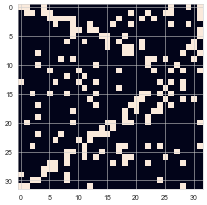

In [54]:
draw(grid)

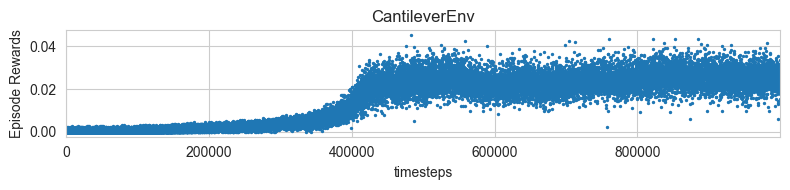

In [55]:
results_plotter.plot_results([log_dir], ts, results_plotter.X_TIMESTEPS, "CantileverEnv")

In [56]:
obs = env.reset()

In [57]:
obs = obs[0]

In [58]:
model_best = PPO.load(log_dir + "best_model.zip", env = env)

In [59]:
ans=[]
for i in range(1000):
    action, _states = model_best.predict(obs)
    obs, rewards, dones, _,infos = env.step(action)
    ans.append(obs)
    if dones:   
        break

In [60]:
OBS = [ans[-1] for i in range(16)]
grid = construct(OBS)


Final Cantilever beam design:


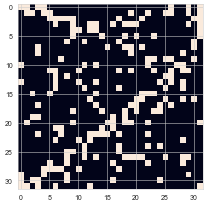

In [61]:
draw(grid)

In [62]:
args = get_args(*mbb_beam(rd=0))
tmp, const = fast_stopt(args, grid.astype(float))

In [63]:
tmp

768.4519276632146

In [64]:
const

0.189453125

In [65]:
grid

array([[1, 1, 0, ..., 1, 0, 1],
       [0, 1, 1, ..., 1, 0, 1],
       [0, 0, 0, ..., 0, 1, 1],
       ...,
       [1, 0, 0, ..., 1, 0, 0],
       [1, 0, 1, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 1]])

In [66]:
arr = grid

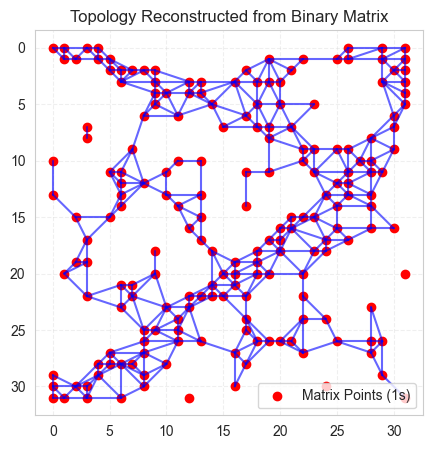

Topological Features found:
Hole/Loop exists from radius 2.25 to 11.275510204081632
Hole/Loop exists from radius 2.5 to 9.438775510204081
Hole/Loop exists from radius 4.5 to 10.890625
Hole/Loop exists from radius 1.25 to 7.25
Hole/Loop exists from radius 3.25 to 7.540000000000001
Hole/Loop exists from radius 2.5 to 6.640625
Hole/Loop exists from radius 3.25 to 7.309688581314877
Hole/Loop exists from radius 4.25 to 7.652354570637107
Hole/Loop exists from radius 2.5 to 5.555555555555563
Hole/Loop exists from radius 3.25 to 6.2869822485207125
Hole/Loop exists from radius 3.25 to 6.25
Hole/Loop exists from radius 1.25 to 3.25
Hole/Loop exists from radius 4.0 to 5.637755102040815
Hole/Loop exists from radius 6.25 to 7.652354570637122
Hole/Loop exists from radius 4.25 to 5.637755102040824
Hole/Loop exists from radius 1.25 to 2.5000000000000004
Hole/Loop exists from radius 1.25 to 2.5000000000000004
Hole/Loop exists from radius 2.25 to 3.379999999999999
Hole/Loop exists from radius 2.0 to 3.1

In [67]:
# 1. Convert Matrix to Point Cloud
# np.argwhere finds indices where value is 1
points = np.argwhere(arr == 1)

# 2. Build the Alpha Complex
# This reconstructs the topological structure from the discrete points
alpha_complex = gd.AlphaComplex(points=points)
simplex_tree = alpha_complex.create_simplex_tree()

# 3. Visualization
plt.figure(figsize=(5, 5))

# Plot the original matrix points
plt.scatter(points[:, 1], points[:, 0], c='red', label='Matrix Points (1s)')

# Reconstruct and plot the edges (1-simplices)
# Adjust alpha_threshold to "connect" points at different distances
alpha_threshold = 3
for simplex, filtration in simplex_tree.get_skeleton(1):
    if len(simplex) == 2 and filtration < alpha_threshold:
        p1, p2 = points[simplex[0]], points[simplex[1]]
        # Note: argwhere returns (row, col), so we plot (col, row) for (x, y)
        plt.plot([p1[1], p2[1]], [p1[0], p2[0]], 'b-', alpha=0.6)

plt.gca().invert_yaxis() # Match matrix coordinate system (top-down)
plt.title("Topology Reconstructed from Binary Matrix")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# 4. Extract Topological Invariants
persistence = simplex_tree.persistence()
print("Topological Features found:")
for dim, (birth, death) in persistence:
    feature_type = "Component" if dim == 0 else "Hole/Loop"
    print(f"{feature_type} exists from radius {birth} to {death}")

In [68]:
pool.close()   
pool.join()